# Breast Cancer Detection with ML
> Using Open-source UCI repository dataset, we will train the model of breast cancer detection. K-nearest neighborhood and Support Vector Machine will be used. In this data, the goal is to predict malignant or benign based on some features.

- toc: true
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Machine_Learning]
- image: images/breast_cancer.png

## Required Packages

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from pandas.plotting import scatter_matrix

## Version Check

In [2]:
print('Python: {}'.format(sys.version))
print('Numpy: {}'.format(np.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Pandas: {}'.format(pd.__version__))
print('Scikit-learn: {}'.format(sklearn.__version__))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Numpy: 2.1.3
Matplotlib: 3.10.0
Pandas: 2.2.3
Scikit-learn: 1.6.1


## Dataset Load
More data information is in [here](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29)

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
names = ['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
         'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei',
         'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

df = pd.read_csv(url, names=names).replace('?', np.nan).dropna()

In [4]:
df.head()

,id,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## Preprocess data

In [5]:
# Drop useless feature for classification
df.drop(['id'], axis=1, inplace=True)

## Summarize Dataset

In [6]:
print(df.describe())

       clump_thickness  uniform_cell_size  uniform_cell_shape  \
count       683.000000         683.000000          683.000000   
mean          4.442167           3.150805            3.215227   
std           2.820761           3.065145            2.988581   
min           1.000000           1.000000            1.000000   
25%           2.000000           1.000000            1.000000   
50%           4.000000           1.000000            1.000000   
75%           6.000000           5.000000            5.000000   
max          10.000000          10.000000           10.000000   

       marginal_adhesion  single_epithelial_size  bland_chromatin  \
count         683.000000              683.000000       683.000000   
mean            2.830161                3.234261         3.445095   
std             2.864562                2.223085         2.449697   
min             1.000000                1.000000         1.000000   
25%             1.000000                2.000000         2.000000   


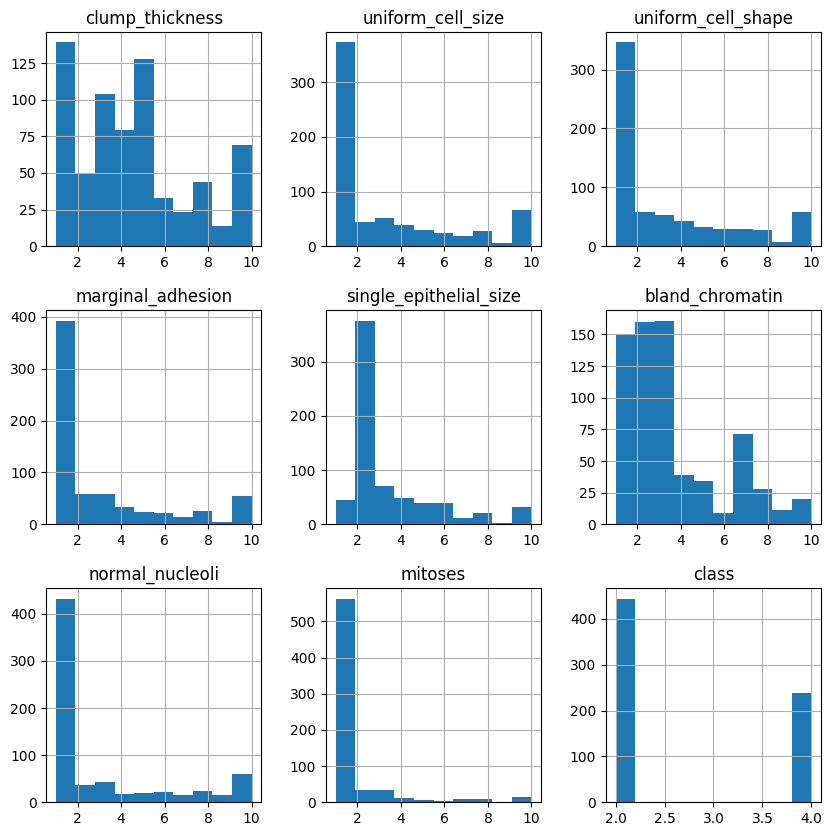

In [7]:
# Plot histograms for each variable
df.hist(figsize=(10, 10));

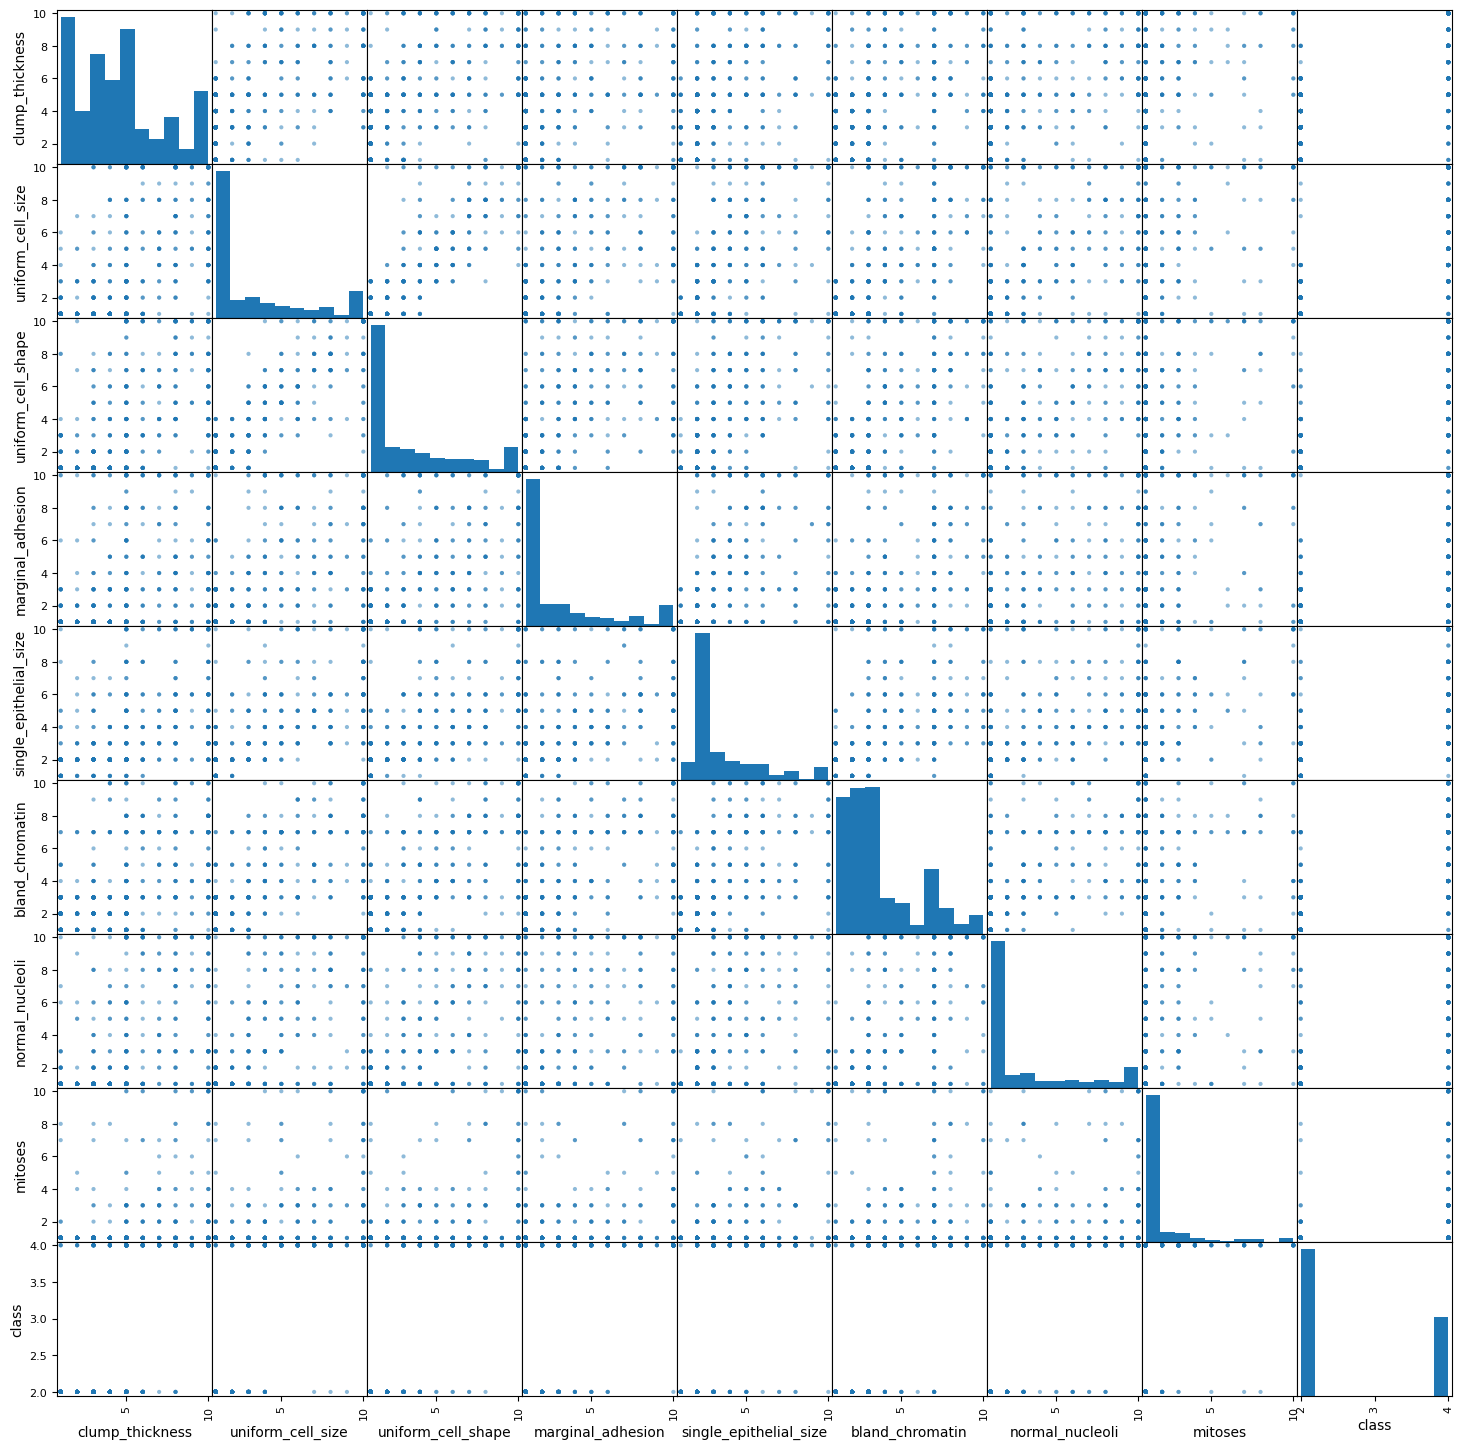

In [8]:
# Create scatter plot matrix
scatter_matrix(df, figsize=(18, 18));

## Split Train/Test data

In [9]:
X = df.drop(['class'], axis=1).to_numpy()
y = df['class'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Specify Test options

In [10]:
seed = 8
scoring = 'accuracy'

## Define the model to train


In [11]:
models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models.append(('SVM', SVC()))

# Evaluate each model in turn
results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

KNN: 0.968855 (0.020159)
SVM: 0.976195 (0.014310)


## Make Predictions on validation dataset

In [12]:
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(name)
    print(accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

KNN
0.9854014598540146
              precision    recall  f1-score   support

           2       0.98      1.00      0.99        83
           4       1.00      0.96      0.98        54

    accuracy                           0.99       137
   macro avg       0.99      0.98      0.98       137
weighted avg       0.99      0.99      0.99       137

SVM
0.9635036496350365
              precision    recall  f1-score   support

           2       0.96      0.98      0.97        83
           4       0.96      0.94      0.95        54

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



## Another way to get accuracy

In [13]:
clf = SVC()
clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(accuracy)

0.9635036496350365


## Test it with samples

In [14]:
example = np.array([[4, 2, 1, 1, 1, 2, 3, 2, 10]])
example = example.reshape(len(example), -1)
prediction = clf.predict(example)
print(prediction)

[2]


In [15]:
example = np.array([[10, 2, 1, 1, 1, 2, 3, 2, 10]])
example = example.reshape(len(example), -1)
prediction = clf.predict(example)
print(prediction)

[4]


=== MODEL COMPARISON RESULTS ===
                 Model  Accuracy (%)  Precision  Recall  F1-Score
   Logistic Regression         98.25     0.9861  0.9861    0.9861
Support Vector Machine         98.25     0.9861  0.9861    0.9861
         Random Forest         95.61     0.9589  0.9722    0.9655
   K-Nearest Neighbors         95.61     0.9589  0.9722    0.9655
     Gradient Boosting         95.61     0.9467  0.9861    0.9660
           Naive Bayes         92.98     0.9444  0.9444    0.9444
         Decision Tree         91.23     0.9559  0.9028    0.9286


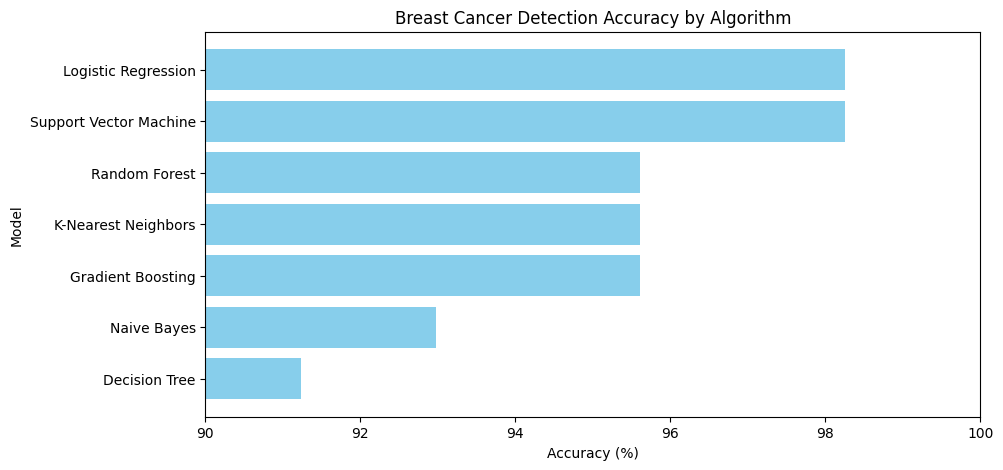

In [16]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 2. Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 3. Train/Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Dictionary of Models to Train
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Train all models and log metrics
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# 6. Display Performance Summary Table
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("=== MODEL COMPARISON RESULTS ===")
print(results_df.to_string(index=False))

# 7. Plot Accuracy Bar Chart
plt.figure(figsize=(10, 5))
plt.barh(results_df["Model"], results_df["Accuracy (%)"], color='skyblue')
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("Breast Cancer Detection Accuracy by Algorithm")
plt.xlim(90, 100)
plt.gca().invert_yaxis()
plt.show()